In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── Config — same values as DataTransformationConfig ────────────
DATA_DIR     = r"C:\Users\shubh\OneDrive\Desktop\MLOPs\MLOPs-Project-02\artifacts\06_08_2026_22_22_06\data_ingestion\raw\chest_xray"  
TRAIN_DIR    = os.path.join(DATA_DIR, 'train')
TEST_DIR     = os.path.join(DATA_DIR, 'test')
VAL_DIR      = os.path.join(DATA_DIR, 'val')
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 0    # set to 0 for notebook safety
MEAN         = [0.485, 0.456, 0.406]
STD          = [0.229, 0.224, 0.225]

print('Libraries loaded.')

Libraries loaded.


In [16]:
# ── Train transforms: resize + augmentation + normalize ─────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(size=IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Test/Val transforms: resize + normalize only ─────────────────
test_val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Raw transform: resize only, no normalize — for visualization ─
# Normalized tensors look washed out when plotted.
# We use this only in the visualization cells below.
raw_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print('Transforms defined.')
print('\nTrain pipeline:')
for t in train_transforms.transforms:
    print(f'  → {t}')

Transforms defined.

Train pipeline:
  → Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  → RandomHorizontalFlip(p=0.5)
  → RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
  → ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
  → RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
  → ToTensor()
  → Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


In [17]:
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("VAL_DIR  :", VAL_DIR)

import os
print("TRAIN exists?", os.path.exists(TRAIN_DIR))
print("TEST exists? ", os.path.exists(TEST_DIR))
print("VAL exists?  ", os.path.exists(VAL_DIR))

TRAIN_DIR: C:\Users\shubh\OneDrive\Desktop\MLOPs\MLOPs-Project-02\artifacts\06_08_2026_22_22_06\data_ingestion\raw\chest_xray\train
TEST_DIR : C:\Users\shubh\OneDrive\Desktop\MLOPs\MLOPs-Project-02\artifacts\06_08_2026_22_22_06\data_ingestion\raw\chest_xray\test
VAL_DIR  : C:\Users\shubh\OneDrive\Desktop\MLOPs\MLOPs-Project-02\artifacts\06_08_2026_22_22_06\data_ingestion\raw\chest_xray\val
TRAIN exists? True
TEST exists?  True
VAL exists?   True


In [ ]:
# BASE_DIR = r"C:\Users\shubh\OneDrive\Desktop\MLOPs\MLOPs-Project-02\artifacts\06_08_2026_22_22_06\data_ingestion\raw\chest_xray"

# TRAIN_DIR = os.path.join(BASE_DIR, "train")
# TEST_DIR  = os.path.join(BASE_DIR, "test")
# VAL_DIR   = os.path.join(BASE_DIR, "val")

In [18]:
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.path.exists(VAL_DIR))

True
True
True


In [19]:
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=test_val_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=test_val_transforms)

print(f'Train size : {len(train_dataset)}')
print(f'Test size  : {len(test_dataset)}')
print(f'Val size   : {len(val_dataset)}')
print(f'\nClass mapping: {train_dataset.class_to_idx}')
print(f'Classes      : {train_dataset.classes}')

# Sanity check — should match EDA counts
label_counts = Counter(train_dataset.targets)
print(f'\nTrain label counts:')
for idx, name in enumerate(train_dataset.classes):
    print(f'  {name} ({idx}): {label_counts[idx]} images')

Train size : 5216
Test size  : 624
Val size   : 16

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Classes      : ['NORMAL', 'PNEUMONIA']

Train label counts:
  NORMAL (0): 1341 images
  PNEUMONIA (1): 3875 images


In [20]:
# Check shape of first 5 samples from each split
for name, dataset in [('train', train_dataset), ('test', test_dataset), ('val', val_dataset)]:
    shapes = set()
    for i in range(min(5, len(dataset))):
        img_tensor, _ = dataset[i]
        shapes.add(tuple(img_tensor.shape))
    print(f'{name} tensor shapes: {shapes}')

# Expected output: {(3, 224, 224)} for all splits
# 3 = RGB channels, 224x224 = resized
img_tensor, label = train_dataset[0]
print(f'\nSample tensor — shape: {img_tensor.shape}, dtype: {img_tensor.dtype}')
print(f'Label: {label} ({train_dataset.classes[label]})')
print(f'Pixel value range after normalize: min={img_tensor.min():.3f}, max={img_tensor.max():.3f}')
print('Note: values outside [0,1] are expected after ImageNet normalization ✅')

train tensor shapes: {(3, 224, 224)}
test tensor shapes: {(3, 224, 224)}
val tensor shapes: {(3, 224, 224)}

Sample tensor — shape: torch.Size([3, 224, 224]), dtype: torch.float32
Label: 0 (NORMAL)
Pixel value range after normalize: min=-2.118, max=2.239
Note: values outside [0,1] are expected after ImageNet normalization ✅


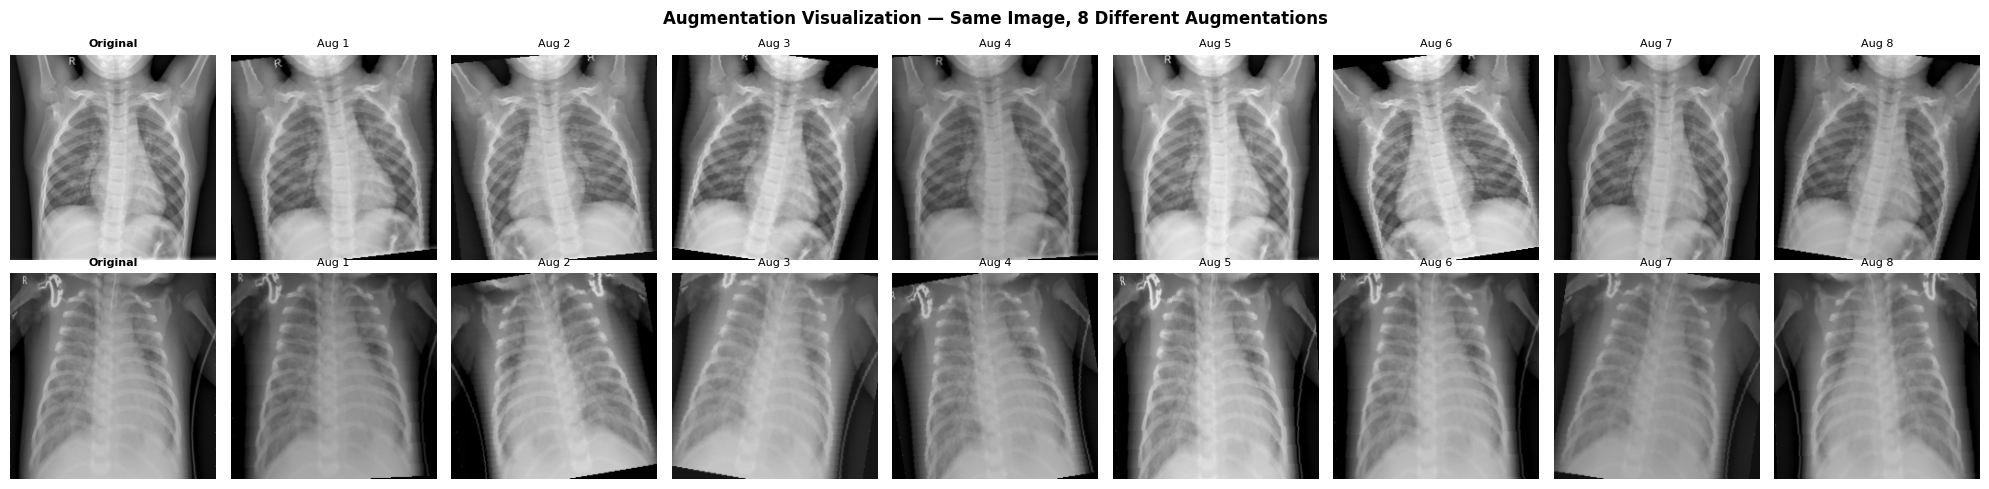

Saved: transformation_augmentation_check.png

Check: Do all augmented images still look like real chest X-rays?
If any look unnatural → reduce rotation degrees or crop scale.


In [10]:
# Helper: denormalize tensor back to displayable image
def denormalize(tensor, mean=MEAN, std=STD):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

# Pick one NORMAL and one PNEUMONIA image
normal_idx    = train_dataset.targets.index(train_dataset.class_to_idx['NORMAL'])
pneumonia_idx = train_dataset.targets.index(train_dataset.class_to_idx['PNEUMONIA'])

# Get raw PIL images so we can apply transforms multiple times
normal_path    = train_dataset.imgs[normal_idx][0]
pneumonia_path = train_dataset.imgs[pneumonia_idx][0]

normal_pil    = Image.open(normal_path).convert('RGB')
pneumonia_pil = Image.open(pneumonia_path).convert('RGB')

fig, axes = plt.subplots(2, 9, figsize=(20, 5))
fig.suptitle('Augmentation Visualization — Same Image, 8 Different Augmentations', fontsize=12, fontweight='bold')

for row, (pil_img, cls_name) in enumerate([(normal_pil, 'NORMAL'), (pneumonia_pil, 'PNEUMONIA')]):
    # First column: original resized, no augmentation
    orig = raw_transforms(pil_img)
    axes[row, 0].imshow(orig.permute(1, 2, 0), cmap='gray')
    axes[row, 0].set_title('Original', fontsize=8, fontweight='bold')
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_ylabel(cls_name, fontsize=10)

    # Columns 1–8: same image with train augmentation applied each time
    for col in range(1, 9):
        aug_tensor = train_transforms(pil_img)
        aug_tensor = denormalize(aug_tensor)
        axes[row, col].imshow(aug_tensor.permute(1, 2, 0), cmap='gray')
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('transformation_augmentation_check.png', dpi=150)
plt.show()
print('Saved: transformation_augmentation_check.png')
print('\nCheck: Do all augmented images still look like real chest X-rays?')
print('If any look unnatural → reduce rotation degrees or crop scale.')

In [11]:
# Compute class weights — mirrors get_class_weights() in production
class_counts = np.bincount(train_dataset.targets)
total        = sum(class_counts)
n_classes    = len(class_counts)

class_weights = torch.tensor(
    [total / (n_classes * count) for count in class_counts],
    dtype=torch.float
)

print('Class weight calculation:')
print(f'  Formula: total / (n_classes x class_count)')
print(f'  Total images : {total}')
print(f'  N classes    : {n_classes}\n')

for cls_name, idx in train_dataset.class_to_idx.items():
    print(f'  {cls_name:<12} count={class_counts[idx]}  weight={class_weights[idx]:.4f}')

print(f'\nClass weights tensor: {class_weights.tolist()}')
print('\nInterpretation:')
print('  Higher weight = model penalised more for wrong predictions on that class.')
print('  NORMAL should have higher weight since it has fewer images.')

Class weight calculation:
  Formula: total / (n_classes x class_count)
  Total images : 5216
  N classes    : 2

  NORMAL       count=1341  weight=1.9448
  PNEUMONIA    count=3875  weight=0.6730

Class weights tensor: [1.944817304611206, 0.673032283782959]

Interpretation:
  Higher weight = model penalised more for wrong predictions on that class.
  NORMAL should have higher weight since it has fewer images.


In [12]:
# ── WeightedRandomSampler for train ──────────────────────────────
sample_weights = [class_weights[label] for label in train_dataset.targets]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=NUM_WORKERS)

# Fetch one batch and check shape
images, labels = next(iter(train_loader))
print(f'Train batch — images: {images.shape}  labels: {labels.shape}')
print(f'Expected    — images: [32, 3, 224, 224]  labels: [32]')
print(f'\nTotal batches — train: {len(train_loader)}  test: {len(test_loader)}  val: {len(val_loader)}')
print(f'\nLabel distribution in this batch: {Counter(labels.tolist())}')
print('(With WeightedRandomSampler this should be roughly 50/50 each batch)')

Train batch — images: torch.Size([32, 3, 224, 224])  labels: torch.Size([32])
Expected    — images: [32, 3, 224, 224]  labels: [32]

Total batches — train: 163  test: 20  val: 1

Label distribution in this batch: Counter({1: 20, 0: 12})
(With WeightedRandomSampler this should be roughly 50/50 each batch)


Across 50 train batches:
  NORMAL    : 779 images (48.7%)
  PNEUMONIA : 821 images (51.3%)

Expected without sampler: ~26% NORMAL / ~74% PNEUMONIA
Expected with    sampler: ~50% NORMAL / ~50% PNEUMONIA


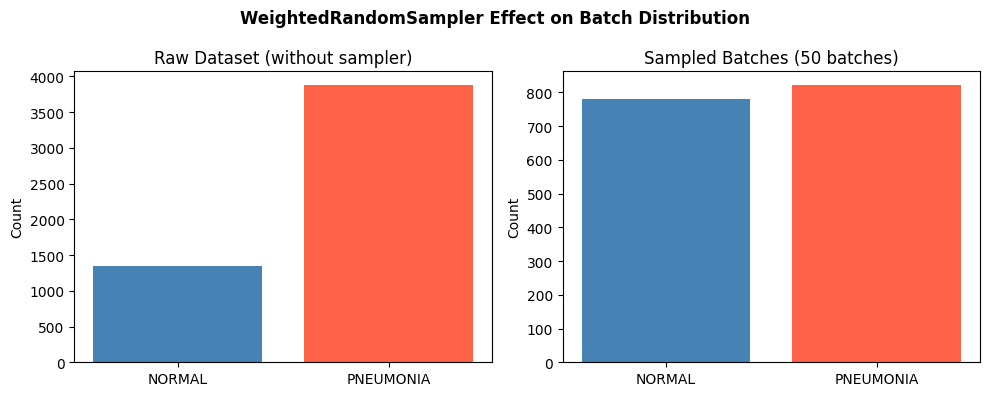

Saved: transformation_sampler_check.png


In [13]:
N_BATCHES     = 50
normal_total    = 0
pneumonia_total = 0

for i, (_, labels) in enumerate(train_loader):
    if i >= N_BATCHES:
        break
    counts = Counter(labels.tolist())
    normal_total    += counts.get(train_dataset.class_to_idx['NORMAL'],    0)
    pneumonia_total += counts.get(train_dataset.class_to_idx['PNEUMONIA'], 0)

total_seen = normal_total + pneumonia_total
print(f'Across {N_BATCHES} train batches:')
print(f'  NORMAL    : {normal_total} images ({100*normal_total/total_seen:.1f}%)')
print(f'  PNEUMONIA : {pneumonia_total} images ({100*pneumonia_total/total_seen:.1f}%)')
print(f'\nExpected without sampler: ~26% NORMAL / ~74% PNEUMONIA')
print(f'Expected with    sampler: ~50% NORMAL / ~50% PNEUMONIA')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['NORMAL', 'PNEUMONIA'], [1341, 3875], color=['steelblue', 'tomato'])
axes[0].set_title('Raw Dataset (without sampler)')
axes[0].set_ylabel('Count')

axes[1].bar(['NORMAL', 'PNEUMONIA'], [normal_total, pneumonia_total], color=['steelblue', 'tomato'])
axes[1].set_title(f'Sampled Batches ({N_BATCHES} batches)')
axes[1].set_ylabel('Count')

plt.suptitle('WeightedRandomSampler Effect on Batch Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('transformation_sampler_check.png', dpi=150)
plt.show()
print('Saved: transformation_sampler_check.png')

In [14]:
print('=' * 55)
print('     DATA TRANSFORMATION VERIFICATION SUMMARY')
print('=' * 55)

images, _ = next(iter(train_loader))
print(f'\n[1] Resize        : {images.shape[2]}x{images.shape[3]} ✅')
print(f'[2] Channels      : {images.shape[1]} (RGB) ✅')
print(f'[3] Batch shape   : {list(images.shape)} ✅')
print(f'[4] Class weights : {[round(w, 4) for w in class_weights.tolist()]} ✅')
print(f'[5] Train batches : {len(train_loader)}')
print(f'    Test batches  : {len(test_loader)}')
print(f'    Val batches   : {len(val_loader)}')
pct = 100 * normal_total / (normal_total + pneumonia_total)
status = '✅' if 40 <= pct <= 60 else '⚠️ check sampler'
print(f'[6] Sampler balance: {pct:.1f}% NORMAL in sampled batches {status}')
print(f'\n{"=" * 55}')
print('Next step: Model Trainer')
print('=' * 55)

     DATA TRANSFORMATION VERIFICATION SUMMARY

[1] Resize        : 224x224 ✅
[2] Channels      : 3 (RGB) ✅
[3] Batch shape   : [32, 3, 224, 224] ✅
[4] Class weights : [1.9448, 0.673] ✅
[5] Train batches : 163
    Test batches  : 20
    Val batches   : 1
[6] Sampler balance: 48.7% NORMAL in sampled batches ✅

Next step: Model Trainer
